# Module 5 - MNIST Data Processing and Classification

This document outlines the implementation of the `MnistData` class, the softmax function, and demonstrates the training/testing images and labels downloaded and converted to `mnist.pkl`.


## Softmax function

In [ ]:
import numpy as np 

In [59]:
def softmax(a):
    """
    Computes the softmax of a given input array.

    Parameters:
    a (array-like): Input array of logits.

    Returns:
    array: Softmax probabilities corresponding to the input.
    """
    return np.exp(a) / np.sum(np.exp(a))


Updated softmax function to prevent overflow

In [60]:
def softmax_updated(a):
    """
    Computes the softmax of a given input array with numerical stability.

    This version shifts the input by the maximum value to prevent overflow.

    Parameters:
    a (array-like): Input array of logits.

    Returns:
    array: Softmax probabilities corresponding to the input.
    """
    c = np.max(a)  # Shift by the maximum value
    exp_a = np.exp(a - c)
    return exp_a / np.sum(exp_a)


In [61]:
# Test the function with different examples
examples = [
    np.array([1.0, 2.0, 3.0]),  # Regular small values
    np.array([900, 1000]),       # Large values that caused overflow before
]
for example in examples:
    print(softmax(example))
    print(softmax_updated(example))
    print("========================")



[0.09003057 0.24472847 0.66524096]
[0.09003057 0.24472847 0.66524096]
[nan nan]
[3.72007598e-44 1.00000000e+00]


C:\Users\Risha\AppData\Local\Temp\ipykernel_7368\3349379723.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(a) / np.sum(np.exp(a))
C:\Users\Risha\AppData\Local\Temp\ipykernel_7368\3349379723.py:2: RuntimeWarning: invalid value encountered in divide
  return np.exp(a) / np.sum(np.exp(a))


## MNIST dataset download and load utilities


In [62]:
import urllib
import gzip
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

In [63]:
image_size = 28 * 28  # 784
dataset_dir = 'dataset'
dataset_pkl = 'mnist.pkl'
url_base = 'http://jrkwon.com/data/ece5831/mnist/'
key_file = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images':  't10k-images-idx3-ubyte.gz',
    'test_labels':  't10k-labels-idx1-ubyte.gz'
}

### Function to download a specific file

In [64]:
def _download(file_name):
    """
    Downloads a specified file and saves it to the dataset directory.

    This function checks if the dataset directory exists and creates it if it doesn't.
    It also verifies if the file has already been downloaded to avoid redundant downloads.

    Parameters:
    file_name (str): The name of the file to download.

    Returns:
    None
    """
    # Ensure the dataset directory exists
    if not os.path.exists(dataset_dir):
        os.makedirs(dataset_dir)

    file_path = os.path.join(dataset_dir, file_name)

    # Check if the file already exists
    if os.path.exists(file_path):
        print(f'File: {file_name} already exists.')
        return
    
    print(f'Downloading {file_name}...')

    # To resolve 406 Not Acceptable error
    opener = urllib.request.build_opener()
    opener.addheaders = [('Accept', '')]
    urllib.request.install_opener(opener)

    # Download the file
    urllib.request.urlretrieve(url_base + file_name, file_path)
    print('Download complete.')


### Function to download all necessary files

In [65]:
def _download_all():
    """
    Downloads all files specified in the key_file dictionary.

    This function iterates over the file names in the key_file dictionary and 
    calls the `_download` function for each file to ensure all necessary files 
    are downloaded and saved to the dataset directory.

    Returns:
    None
    """
    for file_name in key_file.values():
        _download(file_name)


In [66]:
_download_all()

Download complete.
Download complete.
Download complete.
Download complete.


In [67]:
def _load_images(file_name):
    """
    Loads images from a specified gzip-compressed file.

    This function reads a gzip-compressed file containing image data,
    extracts the images, and reshapes them into the appropriate format.

    Parameters:
    file_name (str): The name of the gzip file containing the images.

    Returns:
    numpy.ndarray: A 2D array of images, where each image is flattened into a 1D array.
    """
    file_path = os.path.join(dataset_dir, file_name)
    with gzip.open(file_path, 'rb') as f:
        images = np.frombuffer(f.read(), np.uint8, offset=16)
    images = images.reshape(-1, image_size)
    return images


In [68]:
def _load_labels(file_name):
    """
    Loads labels from a specified gzip-compressed file.

    This function reads a gzip-compressed file containing label data and
    extracts the labels into a 1D array.

    Parameters:
    file_name (str): The name of the gzip file containing the labels.

    Returns:
    numpy.ndarray: A 1D array of labels corresponding to the images.
    """
    file_path = os.path.join(dataset_dir, file_name)
    with gzip.open(file_path, 'rb') as f:
        labels = np.frombuffer(f.read(), np.uint8, offset=8)
    return labels


In [69]:
test_images = _load_images(key_file['test_images'])
test_labels = _load_labels(key_file['test_labels'])

In [72]:
idx = 5500  # Choose an arbitrary index
image_sample = test_images[idx].reshape(28, 28)  # Reshape the flattened image
label_sample = test_labels[idx]

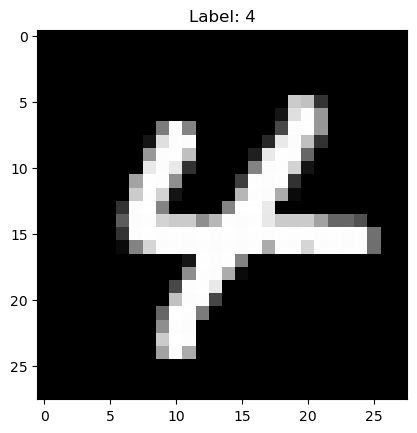

In [73]:
plt.imshow(image_sample, cmap='gray')
plt.title(f"Label: {label_sample}")
plt.show()

### Function to create a dataset, pickle it, and return the dataset

In [84]:
dataset_dir = 'dataset'

In [85]:
def _create_dataset():
    """
    Creates and saves a dataset containing training and testing images and labels.

    This function loads images and labels for both the training and testing datasets,
    combines them into a dictionary, and saves the dataset as a pickle file.

    Returns:
    dict: A dictionary containing training and testing images and labels.
    """
    dataset = {}

    # Load the images and labels for both train and test sets
    dataset['train_images'] = _load_images(os.path.join(dataset_dir, key_file['train_images']))
    dataset['train_labels'] = _load_labels(os.path.join(dataset_dir, key_file['train_labels']))
    dataset['test_images']  = _load_images(os.path.join(dataset_dir, key_file['test_images']))
    dataset['test_labels']  = _load_labels(os.path.join(dataset_dir, key_file['test_labels']))

    # Save the dataset as a pickle file
    with open(os.path.join(dataset_dir, dataset_pkl), 'wb') as f:
        print(f'Pickle: {os.path.join(dataset_dir, dataset_pkl)} is being created.')
        pickle.dump(dataset, f)
        print('Pickling done.')

    return dataset


In [86]:
dataset = _create_dataset

In [97]:
def _create_dataset():
    """
    Creates and saves a dataset containing training and testing images and labels.

    This function loads images and labels for both training and testing datasets,
    prints the shapes of the loaded data, and saves the dataset as a pickle file.

    Returns:
    dict: A dictionary containing the training and testing images and labels.
    """
    dataset = {}

    # Load the images and labels for both train and test sets
    print("Loading training images and labels...")
    dataset['train_images'] = _load_images(key_file['train_images'])
    dataset['train_labels'] = _load_labels(key_file['train_labels'])
    print(f"Train images shape: {dataset['train_images'].shape}")
    print(f"Train labels shape: {dataset['train_labels'].shape}")

    print("Loading testing images and labels...")
    dataset['test_images'] = _load_images(key_file['test_images'])
    dataset['test_labels'] = _load_labels(key_file['test_labels'])
    print(f"Test images shape: {dataset['test_images'].shape}")
    print(f"Test labels shape: {dataset['test_labels'].shape}")

    # Save the dataset as a pickle file
    with open(os.path.join(dataset_dir, dataset_pkl), 'wb') as f:
        print(f'Pickle: {dataset_dir}/{dataset_pkl} is being created.')
        pickle.dump(dataset, f)
        print('Pickling done.')

    return dataset

# Create the dataset and check output
dataset = _create_dataset()


Loading training images and labels...
Train images shape: (60000, 784)
Train labels shape: (60000,)
Loading testing images and labels...
Test images shape: (10000, 784)
Test labels shape: (10000,)
Pickle: dataset/mnist.pkl is being created.
Pickling done.


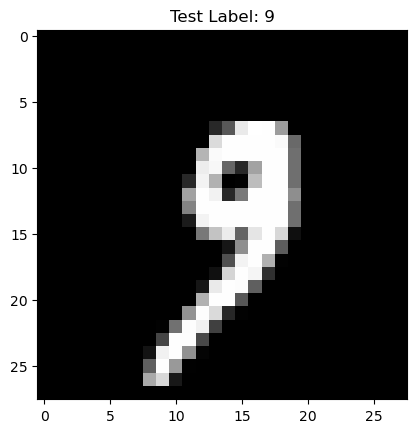

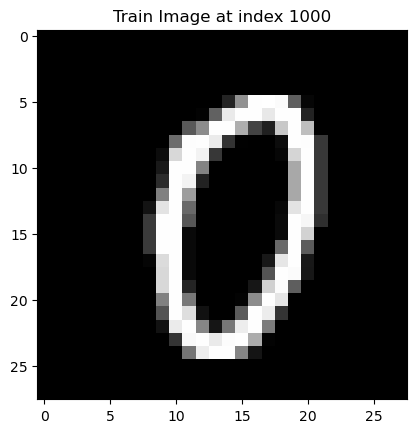

In [98]:
import matplotlib.pyplot as plt

# Display a sample image and its label from the test set
idx = 1000  # Choose an arbitrary index
test_image_sample = dataset['test_images'][idx].reshape(28, 28)
test_label_sample = dataset['test_labels'][idx]

# Plot the test image
plt.imshow(test_image_sample, cmap='gray')
plt.title(f"Test Label: {test_label_sample}")
plt.show()

# Display a sample image from the training set
train_image_sample = dataset['train_images'][idx].reshape(28, 28)
plt.imshow(train_image_sample, cmap='gray')
plt.title(f"Train Image at index {idx}")
plt.show()


In [99]:
def _change_one_hot_label(y, num_class):
    """
    Converts a label array into a one-hot encoded format.

    This function takes an array of labels and converts it into a one-hot encoded 
    matrix, where each label is represented by a row with a 1 at the index of the 
    label and 0s elsewhere.

    Parameters:
    y (numpy.ndarray): A 1D array of integer labels.
    num_class (int): The total number of classes for one-hot encoding.

    Returns:
    numpy.ndarray: A 2D array where each row corresponds to a one-hot encoded label.
    """
    # Create an all-zero matrix with shape (number of labels, number of classes)
    t = np.zeros((y.size, num_class))

    # Set the appropriate index in each row to 1 based on the label value
    for idx, row in enumerate(t):
        row[y[idx]] = 1
    
    return t


In [100]:
y = np.array([1, 0, 9, 8])  # Example labels
one_hot_y = _change_one_hot_label(y, 10)  # Convert to one-hot encoding (10 classes)

# Print the original labels and their one-hot encoded versions
print("Original labels:", y)
print("One-hot encoded labels:")
print(one_hot_y)

Original labels: [1 0 9 8]
One-hot encoded labels:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


In [101]:
def _init_dataset():
    """
    Initializes the dataset by downloading files and loading or creating the dataset.

    This function checks if the dataset pickle file already exists. If it does, 
    it loads the dataset from the pickle file. If it doesn't exist, it downloads 
    all necessary files and creates the dataset.

    Returns:
    dict: A dictionary containing the training and testing images and labels.
    """
    _download_all()
    if os.path.exists(f'{dataset_dir}/{dataset_pkl}'):
        with open(f'{dataset_dir}/{dataset_pkl}', 'rb') as f:
            print(f'Pickle: {dataset_dir}/{dataset_pkl} already exists.')
            print('Loading...')
            dataset = pickle.load(f)
            print('Done.')
    else:
        dataset = _create_dataset()

    return dataset


In [103]:
dataset = {}
dataset = _init_dataset()
dataset['train_images'].shape


File: train-images-idx3-ubyte.gz already exists.
File: train-labels-idx1-ubyte.gz already exists.
File: t10k-images-idx3-ubyte.gz already exists.
File: t10k-labels-idx1-ubyte.gz already exists.
Pickle: dataset/mnist.pkl already exists.
Loading...
Done.


(60000, 784)

In [104]:
class MnistData:
    """
    A class to handle the MNIST dataset loading, processing, and storage.

    This class manages the downloading, loading, and preprocessing of the MNIST dataset.
    It supports downloading the dataset from a specified URL, loading images and labels,
    and converting labels to a one-hot encoded format.

    Attributes:
    image_dim (tuple): The dimensions of each image (28, 28).
    image_size (int): The flattened size of each image (784).
    dataset_dir (str): The directory where the dataset is stored.
    dataset_pkl (str): The name of the pickle file for the dataset.
    url_base (str): The base URL for downloading the MNIST dataset.
    key_file (dict): A dictionary mapping dataset keys to file names.

    Methods:
    __init__(): Initializes the dataset, downloading or loading as needed.
    _change_one_hot_label(y, num_class): Converts labels to one-hot encoded format.
    _download(file_name): Downloads a specified file from the URL.
    _download_all(): Downloads all MNIST dataset files.
    _load_images(file_name): Loads and reshapes images from a gzip file.
    _load_labels(file_name): Loads labels from a gzip file.
    _create_dataset(): Loads images and labels, and saves them as a pickle file.
    _init_dataset(): Initializes the dataset by downloading, creating, or loading the pickle file.
    load(): Loads and normalizes the dataset, applying one-hot encoding to labels.
    """

    image_dim = (28, 28)  # Dimensions of each image
    image_size = image_dim[0] * image_dim[1]  # Flattened size of each image
    dataset_dir = 'dataset'
    dataset_pkl = 'mnist.pkl'
    url_base = 'http://jrkwon.com/data/ece5831/mnist/' 

    # File names for train/test images and labels
    key_file = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }

    def __init__(self):
        """Initializes the dataset, downloading or loading as needed."""
        self.dataset = {}
        self.dataset_pkl_path = os.path.join(self.dataset_dir, self.dataset_pkl)

        # Create dataset directory if it doesn't exist
        if not os.path.exists(self.dataset_dir):
            os.mkdir(self.dataset_dir)

        # Initialize the dataset (download, create, or load)
        self._init_dataset()

    def _change_one_hot_label(self, y, num_class):
        """Convert labels to one-hot encoded format."""
        t = np.zeros((y.size, num_class))
        for idx, row in enumerate(t):
            row[y[idx]] = 1
        return t

    def _download(self, file_name):
        """Download the specified file from the URL."""
        file_path = os.path.join(self.dataset_dir, file_name)

        # Skip download if file already exists
        if os.path.exists(file_path):
            print(f'File: {file_name} already exists.')
            return

        print(f'Downloading {file_name}...')
        opener = urllib.request.build_opener()
        opener.addheaders = [('Accept', '')]
        urllib.request.install_opener(opener)
        urllib.request.urlretrieve(self.url_base + file_name, file_path)
        print('Download complete.')

    def _download_all(self):
        """Download all MNIST dataset files."""
        for file_name in self.key_file.values():
            self._download(file_name)

    def _load_images(self, file_name):
        """Load and reshape images from gzip file."""
        with gzip.open(file_name, 'rb') as f:
            images = np.frombuffer(f.read(), np.uint8, offset=16)
        images = images.reshape(-1, self.image_size)
        return images

    def _load_labels(self, file_name):
        """Load labels from gzip file."""
        with gzip.open(file_name, 'rb') as f:
            labels = np.frombuffer(f.read(), np.uint8, offset=8)
        return labels

    def _create_dataset(self):
        """Load images and labels, and save as a pickle file."""
        # Load training data
        self.dataset['train_images'] = self._load_images(os.path.join(self.dataset_dir, self.key_file['train_images']))
        self.dataset['train_labels'] = self._load_labels(os.path.join(self.dataset_dir, self.key_file['train_labels']))

        # Load testing data
        self.dataset['test_images'] = self._load_images(os.path.join(self.dataset_dir, self.key_file['test_images']))
        self.dataset['test_labels'] = self._load_labels(os.path.join(self.dataset_dir, self.key_file['test_labels']))

        # Save dataset as a pickle file
        with open(self.dataset_pkl_path, 'wb') as f:
            print(f'Pickle: {self.dataset_pkl_path} is being created.')
            pickle.dump(self.dataset, f)
            print('Pickling complete.')

    def _init_dataset(self):
        """Initialize the dataset by downloading, creating, or loading the pickle file."""
        self._download_all()

        if os.path.exists(self.dataset_pkl_path):
            print(f'Pickle: {self.dataset_pkl_path} already exists.')
            print('Loading dataset...')
            with open(self.dataset_pkl_path, 'rb') as f:
                self.dataset = pickle.load(f)
            print('Dataset loaded successfully.')
        else:
            self._create_dataset()

    def load(self):
        """Load and normalize dataset, and apply one-hot encoding to labels."""
        # Normalize image datasets
        for key in ('train_images', 'test_images'):
            self.dataset[key] = self.dataset[key].astype(np.float32)
            self.dataset[key] /= 255.0

        # One-hot encoding for labels
        for key in ('train_labels', 'test_labels'):
            self.dataset[key] = self._change_one_hot_label(self.dataset[key], 10)

        return (self.dataset['train_images'], self.dataset['train_labels']), \
               (self.dataset['test_images'], self.dataset['test_labels'])


In [105]:
mnist_data = MnistData()
(train_images, train_labels), (test_images, test_labels) = mnist_data.load()


File: train-images-idx3-ubyte.gz already exists.
File: train-labels-idx1-ubyte.gz already exists.
File: t10k-images-idx3-ubyte.gz already exists.
File: t10k-labels-idx1-ubyte.gz already exists.
Pickle: dataset\mnist.pkl already exists.
Loading dataset...
Dataset loaded successfully.


Training Label (one-hot): [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
Training Label: 5


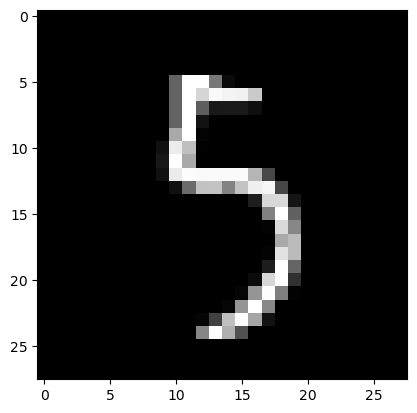

Training Label (one-hot): [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
Training Label: 5


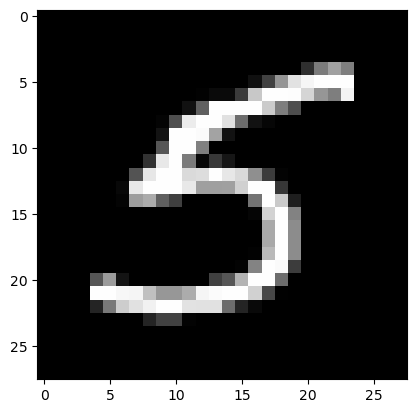

In [106]:
for i in range(2):
    idx = np.random.randint(train_images.shape[0], size=1)
    print(f'Training Label (one-hot): {train_labels[idx]}')
    print(f'Training Label: {np.argmax(train_labels[idx])}')
    plt.imshow(train_images[idx].reshape(28, 28), cmap='gray')
    plt.show()

Testing Label (one-hot): [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Testing Label: 3


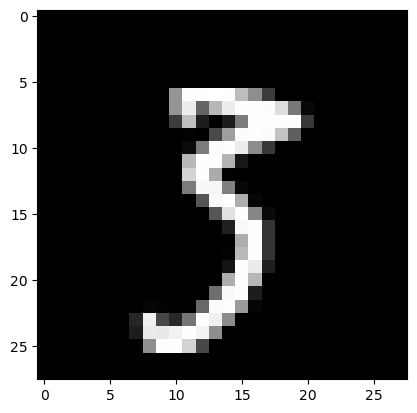

Testing Label (one-hot): [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Testing Label: 1


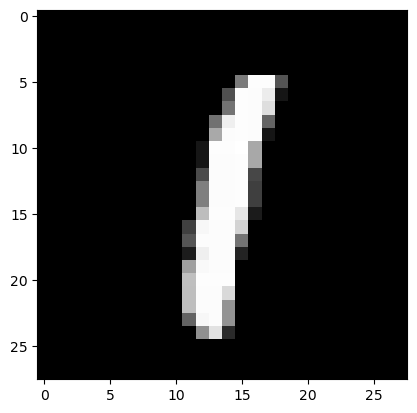

In [107]:
for i in range(2):
    idx = np.random.randint(test_images.shape[0], size=1)
    print(f'Testing Label (one-hot): {test_labels[idx]}')
    print(f'Testing Label: {np.argmax(test_labels[idx])}')
    plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
    plt.show()